# Starbucks Promotion Optimization
## Phase 1 — Event Log Wrangling & the "View" Trap

### Objective

The raw Starbucks dataset contains three JSON files:

- `portfolio.json` — offer metadata
- `profile.json` — customer demographics
- `transcript.json` — time-series customer events

The goal of Phase 1 is to:

1. Load and inspect the raw data.
2. Reconstruct customer-offer journeys.
3. Build an offer-level funnel:
   - Offer Received
   - Offer Viewed
   - Offer Completed
4. Identify accidental completions where an offer was completed without a prior view.
5. Attribute transactions to relevant active offers.
6. Handle overlapping offers using a clearly documented attribution rule.
7. Save clean datasets for Phase 2 feature engineering.

Important:
All treatment/exposure decisions will be based on the reconstructed event history rather than
assuming that every transaction or offer completion represents treatment.

In [ ]:
# IMPORT LIBRARIES

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# DATA PATH


# Assumed project structure:
#
# Starbucks_Uplift_Project/
# │
# ├── data/
# │   ├── portfolio.json
# │   ├── profile.json
# │   └── transcript.json
# │
# └── notebooks/
#     └── 01_event_log_wrangling.ipynb
#
# Therefore, from the notebooks folder:
# ../data/

DATA_DIR = Path("../data")

portfolio_path = DATA_DIR / "portfolio.json"
profile_path = DATA_DIR / "profile.json"
transcript_path = DATA_DIR / "transcript.json"

print("Data directory:", DATA_DIR.resolve())

print("\nFiles:")
print("Portfolio:", portfolio_path)
print("Profile:", profile_path)
print("Transcript:", transcript_path)

Data directory: C:\Starbucks Uplift Assignment\data

Files:
Portfolio: ..\data\portfolio.json
Profile: ..\data\profile.json
Transcript: ..\data\transcript.json


In [ ]:
# VERIFY FILES


required_files = [
    portfolio_path,
    profile_path,
    transcript_path
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(
            f"File not found: {file_path.resolve()}"
        )

print("All required files found.")

All required files found.


In [ ]:
# JSONL LOADER


def load_jsonl(path):
    """
    Load a JSON Lines file.

    Each line in the file contains one independent JSON object.
    The function returns a Python list containing all objects.
    """

    records = []

    with open(path, "r", encoding="utf-8") as f:

        for line_number, line in enumerate(f, start=1):

            line = line.strip()

            # Ignore blank lines
            if not line:
                continue

            try:
                records.append(json.loads(line))

            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON on line {line_number} "
                    f"of {path}: {error}"
                )

    return records


# Load all three datasets
portfolio = load_jsonl(portfolio_path)
profile = load_jsonl(profile_path)
transcript = load_jsonl(transcript_path)


print("Portfolio records :", len(portfolio))
print("Profile records   :", len(profile))
print("Transcript records:", len(transcript))

Portfolio records : 10
Profile records   : 17000
Transcript records: 306534


In [ ]:
# PORTFOLIO DATASET

portfolio_df = pd.DataFrame(portfolio)

# Rename offer ID to a consistent name
portfolio_df = portfolio_df.rename(
    columns={"id": "offer_id"}
)

print("Portfolio shape:", portfolio_df.shape)

display(portfolio_df)

Portfolio shape: (10, 6)


,reward,channels,difficulty,duration,offer_type,offer_id
0,10,"[email, mobile, social]",10,7.0,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5.0,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4.0,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7.0,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10.0,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"[web, email, mobile, social]",7,7.0,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"[web, email, mobile, social]",10,10.0,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"[email, mobile, social]",0,3.0,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"[web, email, mobile, social]",5,5.0,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"[web, email, mobile]",10,7.0,discount,2906b810c7d4411798c6938adc9daaa5


In [ ]:
# PORTFOLIO INSPECTION


print("Portfolio columns:")
print(portfolio_df.columns.tolist())

print("\nOffer types:")
print(portfolio_df["offer_type"].value_counts())

print("\nMissing values:")
print(portfolio_df.isna().sum())

Portfolio columns:
['reward', 'channels', 'difficulty', 'duration', 'offer_type', 'offer_id']

Offer types:
offer_type
bogo             4
discount         4
informational    2
Name: count, dtype: int64

Missing values:
reward        0
channels      0
difficulty    0
duration      0
offer_type    0
offer_id      0
dtype: int64


In [ ]:
# CUSTOMER PROFILE DATASET


profile_df = pd.DataFrame(profile)

# Rename customer ID
profile_df = profile_df.rename(
    columns={"id": "person_id"}
)

print("Profile shape:", profile_df.shape)

display(profile_df.head())

Profile shape: (17000, 5)


,gender,age,person_id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [ ]:
# PROFILE DATA QUALITY


print("Profile columns:")
print(profile_df.columns.tolist())

print("\nMissing values:")
print(profile_df.isna().sum())

print("\nGender distribution:")
print(profile_df["gender"].value_counts(dropna=False))

print("\nAge summary:")
print(profile_df["age"].describe())

print("\nIncome summary:")
print(profile_df["income"].describe())

Profile columns:
['gender', 'age', 'person_id', 'became_member_on', 'income']

Missing values:
gender              2175
age                    0
person_id              0
became_member_on       0
income              2175
dtype: int64

Gender distribution:
gender
M      8484
F      6129
NaN    2175
O       212
Name: count, dtype: int64

Age summary:
count    17000.000000
mean        62.531412
std         26.738580
min         18.000000
25%         45.000000
50%         58.000000
75%         73.000000
max        118.000000
Name: age, dtype: float64

Income summary:
count     14825.000000
mean      65404.991568
std       21598.299410
min       30000.000000
25%       49000.000000
50%       64000.000000
75%       80000.000000
max      120000.000000
Name: income, dtype: float64


In [ ]:
# CLEAN PROFILE VALUES



profile_df["demo_missing"] = profile_df["age"].eq(118)
profile_df["age"] = profile_df["age"].replace(118, np.nan)

In [ ]:
# TRANSCRIPT DATASET


transcript_df = pd.DataFrame(transcript)

# Rename person column
transcript_df = transcript_df.rename(
    columns={"person": "person_id"}
)

print("Transcript shape:", transcript_df.shape)

print("\nColumns:")
print(transcript_df.columns.tolist())

display(transcript_df.head())

Transcript shape: (306534, 4)

Columns:
['person_id', 'event', 'value', 'time']


,person_id,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [ ]:
# EVENT DISTRIBUTION


event_counts = transcript_df["event"].value_counts()

print(event_counts)

event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64


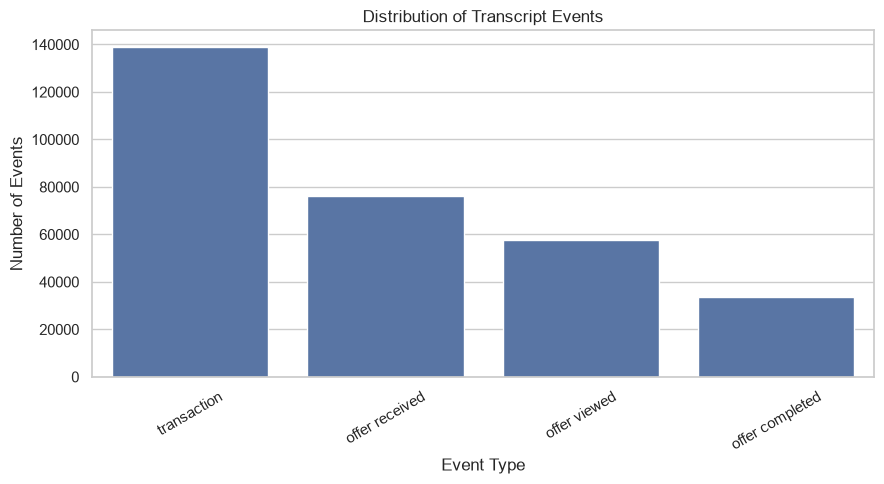

In [ ]:
# EVENT DISTRIBUTION PLOT


plt.figure(figsize=(9, 5))

sns.barplot(
    x=event_counts.index,
    y=event_counts.values
)

plt.title("Distribution of Transcript Events")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# TIME RANGE


print("Minimum event time:", transcript_df["time"].min())
print("Maximum event time:", transcript_df["time"].max())

print(
    "\nApproximate observation period:",
    round(
        (transcript_df["time"].max() -
         transcript_df["time"].min()) / 24,
        2
    ),
    "days"
)

Minimum event time: 0
Maximum event time: 714

Approximate observation period: 29.75 days


In [ ]:
# EXTRACT INFORMATION FROM EVENT VALUE


def extract_offer_id(value):
    """
    Extract offer ID from an event's value dictionary.
    Handles both:
        'offer id'
        'offer_id'
    """

    if not isinstance(value, dict):
        return None

    return value.get(
        "offer id",
        value.get("offer_id")
    )


def extract_amount(value):
    """
    Extract transaction amount.
    """

    if not isinstance(value, dict):
        return None

    return value.get("amount")


def extract_reward(value):
    """
    Extract reward associated with an offer completion.
    """

    if not isinstance(value, dict):
        return None

    return value.get("reward")


# Create standardized columns
transcript_df["offer_id"] = (
    transcript_df["value"]
    .apply(extract_offer_id)
)

transcript_df["amount"] = (
    transcript_df["value"]
    .apply(extract_amount)
)

transcript_df["event_reward"] = (
    transcript_df["value"]
    .apply(extract_reward)
)

print("Extracted event-level fields successfully.")

Extracted event-level fields successfully.


In [ ]:
# EVENT DATA QUALITY CHECK


print("Missing offer IDs:")
print(
    transcript_df.groupby("event")["offer_id"]
    .apply(lambda x: x.isna().sum())
)

print("\nMissing transaction amounts:")
print(
    transcript_df.groupby("event")["amount"]
    .apply(lambda x: x.isna().sum())
)

print("\nMissing event rewards:")
print(
    transcript_df.groupby("event")["event_reward"]
    .apply(lambda x: x.isna().sum())
)

Missing offer IDs:
event
offer completed         0
offer received          0
offer viewed            0
transaction        138953
Name: offer_id, dtype: int64

Missing transaction amounts:
event
offer completed    33579
offer received     76277
offer viewed       57725
transaction            0
Name: amount, dtype: int64

Missing event rewards:
event
offer completed         0
offer received      76277
offer viewed        57725
transaction        138953
Name: event_reward, dtype: int64


In [ ]:
# OFFER-RELATED EVENTS


offer_event_types = [
    "offer received",
    "offer viewed",
    "offer completed"
]

offer_events = transcript_df[
    transcript_df["event"].isin(offer_event_types)
].copy()

print("Offer event records:", len(offer_events))

display(offer_events.head())

Offer event records: 167581


,person_id,event,value,time,offer_id,amount,event_reward
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN


In [ ]:
# ADD OFFER METADATA


portfolio_metadata = portfolio_df[
    [
        "offer_id",
        "offer_type",
        "difficulty",
        "duration",
        "channels"
    ]
].copy()

offer_events = offer_events.merge(
    portfolio_metadata,
    on="offer_id",
    how="left"
)

# Sort events chronologically
offer_events = offer_events.sort_values(
    ["person_id", "offer_id", "time"]
).reset_index(drop=True)

print("Offer event table shape:", offer_events.shape)

display(offer_events.head())

Offer event table shape: (167581, 11)


,person_id,event,value,time,offer_id,amount,event_reward,offer_type,difficulty,duration,channels
0,0009655768c64bdeb2e877511632db8f,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},576,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,discount,10,7.0,"[web, email, mobile]"
1,0009655768c64bdeb2e877511632db8f,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,576,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,discount,10,7.0,"[web, email, mobile]"
2,0009655768c64bdeb2e877511632db8f,offer received,{'offer id': '3f207df678b143eea3cee63160fa8bed'},336,3f207df678b143eea3cee63160fa8bed,NaN,NaN,informational,0,4.0,"[web, email, mobile]"
3,0009655768c64bdeb2e877511632db8f,offer viewed,{'offer id': '3f207df678b143eea3cee63160fa8bed'},372,3f207df678b143eea3cee63160fa8bed,NaN,NaN,informational,0,4.0,"[web, email, mobile]"
4,0009655768c64bdeb2e877511632db8f,offer received,{'offer id': '5a8bc65990b245e5a138643cd4eb9837'},168,5a8bc65990b245e5a138643cd4eb9837,NaN,NaN,informational,0,3.0,"[email, mobile, social]"


In [ ]:
# CHECK OFFER METADATA MATCHING


missing_metadata = offer_events[
    offer_events["offer_type"].isna()
]

print(
    "Offer events without portfolio metadata:",
    len(missing_metadata)
)

if len(missing_metadata) > 0:
    print(
        missing_metadata["offer_id"]
        .dropna()
        .unique()
    )

Offer events without portfolio metadata: 0


In [ ]:
# CUSTOMER-OFFER FUNNEL

#  ONE ROW PER RECEIVED INSTANCE

received = (
    offer_events.loc[offer_events["event"] == "offer received", ["person_id", "offer_id", "time"]]
    .rename(columns={"time": "time_received"})
    .sort_values(["time_received", "person_id", "offer_id"])
    .reset_index(drop=True)
)
received["instance_id"] = np.arange(len(received))

print("Received events      :", (offer_events["event"] == "offer received").sum())
print("Received instances   :", len(received))
assert len(received) == (offer_events["event"] == "offer received").sum()
    

Received events      : 76277
Received instances   : 76277


In [ ]:
# MATCH VIEW / COMPLETION EVENTS TO THEIR INSTANCE

def attach_to_instance(event_name, new_col, agg="min", extra=None):
    ev = offer_events.loc[offer_events["event"] == event_name,
                          ["person_id", "offer_id", "time"] + ([extra] if extra else [])].copy()
    ev = ev.rename(columns={"time": new_col}).sort_values(new_col)

    # backward = latest received instance whose time_received <= event time
    m = pd.merge_asof(
        ev, received.sort_values("time_received"),
        left_on=new_col, right_on="time_received",
        by=["person_id", "offer_id"], direction="backward",
    ).dropna(subset=["instance_id"])
    m["instance_id"] = m["instance_id"].astype(int)

    aggs = {new_col: agg}
    if extra:
        aggs[extra] = "max"
    return m.groupby("instance_id").agg(aggs)

views = attach_to_instance("offer viewed", "time_viewed")
comps = attach_to_instance("offer completed", "time_completed", extra="event_reward")
comps = comps.rename(columns={"event_reward": "reward_used"})

offer_funnel = (
    received.merge(views, on="instance_id", how="left")
            .merge(comps, on="instance_id", how="left")
            .merge(portfolio_df.rename(columns={"reward": "offer_reward"}), on="offer_id", how="left")
)
offer_funnel["offer_end"] = offer_funnel["time_received"] + offer_funnel["duration"] * 24
offer_funnel = offer_funnel.sort_values(["person_id", "time_received", "offer_id"]).reset_index(drop=True)

# sanity: nothing should be matched to an instance that has already expired by more than 0h
print("Instance funnel shape:", offer_funnel.shape)
print("Views matched         :", offer_funnel["time_viewed"].notna().sum(), "(raw view events:", (offer_events.event=='offer viewed').sum(), ")")
print("Completions matched   :", offer_funnel["time_completed"].notna().sum(), "(raw completion events:", (offer_events.event=='offer completed').sum(), ")")

Instance funnel shape: (76277, 13)
Views matched         : 57725 (raw view events: 57725 )
Completions matched   : 33101 (raw completion events: 33579 )


In [ ]:
# FUNNEL FLAGS

 
offer_funnel["viewed"]    = offer_funnel["time_viewed"].notna().astype(int)
offer_funnel["completed"] = offer_funnel["time_completed"].notna().astype(int)

print("Total offer instances:", len(offer_funnel))
print("Viewed               :", offer_funnel["viewed"].sum())
print("Completed            :", offer_funnel["completed"].sum())


Total offer instances: 76277
Viewed               : 57725
Completed            : 33101


In [ ]:
# FUNNEL SUMMARY


total_received = len(offer_funnel)

total_viewed = offer_funnel["viewed"].sum()

total_completed = offer_funnel["completed"].sum()

print("========== OFFER FUNNEL ==========")

print(
    f"Received   : {total_received:,}"
)

print(
    f"Viewed     : {total_viewed:,} "
    f"({total_viewed / total_received:.2%})"
)

print(
    f"Completed  : {total_completed:,} "
    f"({total_completed / total_received:.2%})"
)

print(
    f"View → Complete: "
    f"{total_completed / total_viewed:.2%}"
)

========== OFFER FUNNEL ==========
Received   : 76,277
Viewed     : 57,725 (75.68%)
Completed  : 33,101 (43.40%)
View → Complete: 57.34%


In [ ]:
# FUNNEL BY OFFER TYPE


funnel_by_type = (
    offer_funnel
    .groupby("offer_type")
    .agg(
        received=("offer_id", "count"),
        viewed=("viewed", "sum"),
        completed=("completed", "sum")
    )
    .reset_index()
)

funnel_by_type["view_rate"] = (
    funnel_by_type["viewed"]
    / funnel_by_type["received"]
)

funnel_by_type["completion_rate"] = (
    funnel_by_type["completed"]
    / funnel_by_type["received"]
)

funnel_by_type

,offer_type,received,viewed,completed,view_rate,completion_rate
0,bogo,30499,25449,15501,0.834421,0.508246
1,discount,30543,21445,17600,0.702125,0.576237
2,informational,15235,10831,0,0.710929,0.000000


In [ ]:
# ACCIDENTAL COMPLETIONS(VIEW TRAP)


f = offer_funnel
f["view_status"] = np.select(
    [
        f["time_viewed"].isna(),
        f["time_viewed"] > f["time_completed"].fillna(np.inf),   # seen only after finishing
    ],
    ["never_viewed", "viewed_after_completion"],
    default="viewed_before_completion",
)
# for offers that were never completed, view status is simply viewed / not viewed
f.loc[f["completed"] == 0, "view_status"] = np.where(
    f.loc[f["completed"] == 0, "viewed"] == 1, "viewed_not_completed", "not_viewed_not_completed"
)

f["accidental_completion"] = (
    (f["completed"] == 1) & (f["view_status"].isin(["never_viewed", "viewed_after_completion"]))
).astype(int)

done = f[f["completed"] == 1]
print("Completed instances :", len(done))
print(done["view_status"].value_counts().to_string())
print(f"\nAccidental completions: {f['accidental_completion'].sum():,} ({f['accidental_completion'].sum()/len(done):.1%} of completions)")
display(done.groupby("offer_type")["accidental_completion"].agg(completed="size", accidental="sum", rate="mean"))

basic_view_trap = f[f["accidental_completion"] == 1].copy()     # keeps the name used by your save cell

Completed instances : 33101
view_status
viewed_before_completion    23267
never_viewed                 5629
viewed_after_completion      4205

Accidental completions: 9,834 (29.7% of completions)


,completed,accidental,rate
offer_type,,,
bogo,15501,4560,0.294175
discount,17600,5274,0.299659


In [ ]:
# TRANSACTION EVENTS


transactions = transcript_df[
    transcript_df["event"] == "transaction"
].copy()

transactions = transactions[
    [
        "person_id",
        "time",
        "amount"
    ]
].copy()

transactions = transactions.rename(
    columns={
        "time": "transaction_time"
    }
)

transactions = transactions.sort_values(
    ["person_id", "transaction_time"]
).reset_index(drop=True)

print("Transactions:", len(transactions))

display(transactions.head())

Transactions: 138953


,person_id,transaction_time,amount
0,0009655768c64bdeb2e877511632db8f,228,22.16
1,0009655768c64bdeb2e877511632db8f,414,8.57
2,0009655768c64bdeb2e877511632db8f,528,14.11
3,0009655768c64bdeb2e877511632db8f,552,13.56
4,0009655768c64bdeb2e877511632db8f,576,10.27


In [ ]:
# TRANSACTION SUMMARY


print("Transaction count:", len(transactions))

print(
    "Unique customers with transactions:",
    transactions["person_id"].nunique()
)

print("\nTransaction amount summary:")

display(
    transactions["amount"].describe()
)

Transaction count: 138953
Unique customers with transactions: 16578

Transaction amount summary:


count    138953.000000
mean         12.777356
std          30.250529
min           0.050000
25%           2.780000
50%           8.890000
75%          18.070000
max        1062.280000
Name: amount, dtype: float64

Treatment rule. An offer instance is treated only if the customer viewed it before completing or purchasing. Accidental completions (never viewed, or viewed only after completing) are assigned to control, because an offer the customer had not seen cannot have influenced the purchase. Alternatives are tested in the sensitivity table below.

In [ ]:
# WINDOW OUTCOME: spend inside each offer's active window

tx = transactions[["person_id", "transaction_time", "amount"]].sort_values("transaction_time")

def window_spend(funnel):
    # cumulative-sum lookup per customer
    out = np.zeros(len(funnel))
    tx_by = {p: (g["transaction_time"].values, np.concatenate([[0], g["amount"].values.cumsum()]))
             for p, g in tx.groupby("person_id")}
    for i, (p, s, e) in enumerate(zip(funnel["person_id"], funnel["time_received"], funnel["offer_end"])):
        if p in tx_by:
            t, cs = tx_by[p]
            lo = np.searchsorted(t, s, side="left")
            hi = np.searchsorted(t, e, side="right")
            out[i] = cs[hi] - cs[lo]
    return out

offer_funnel["window_spend"] = window_spend(offer_funnel)
offer_funnel["time_to_complete"] = offer_funnel["time_completed"] - offer_funnel["time_received"]
print(offer_funnel["window_spend"].describe().round(2))

count    76277.00
mean        27.36
std         54.74
min          0.00
25%          1.34
50%         12.33
75%         35.39
max       1200.99
Name: window_spend, dtype: float64


In [ ]:
# DOES THE ACCIDENTAL GROUP BEHAVE LIKE VIEWERS OR LIKE NON-VIEWERS?

from scipy import stats
promo = offer_funnel[offer_funnel["offer_type"].isin(["bogo", "discount"])].copy()

promo["group"] = np.select(
    [promo["accidental_completion"] == 1,
     (promo["viewed"] == 1) & (promo["accidental_completion"] == 0)],
    ["accidental", "viewed_normal"], default="never_viewed_no_completion")

summary = promo.groupby("group").agg(
    n=("group", "size"),
    mean_window_spend=("window_spend", "mean"),
    median_window_spend=("window_spend", "median"),
    mean_difficulty=("difficulty", "mean"),
    share_bogo=("offer_type", lambda s: (s == "bogo").mean()),
).round(2)
display(summary)

# Spend distributions are right-skewed -> Mann-Whitney, not t-test
acc = promo.loc[promo.group == "accidental", "window_spend"]
for other in ["viewed_normal", "never_viewed_no_completion"]:
    o = promo.loc[promo.group == other, "window_spend"]
    u, p = stats.mannwhitneyu(acc, o, alternative="two-sided")
    print(f"accidental vs {other:28s}: Mann-Whitney p = {p:.2e}")

# Do accidental completions concentrate in particular offers? (difficulty = spend needed)
ct = pd.crosstab(promo["offer_id"], promo["accidental_completion"])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"\nAccidental rate differs across offers: chi2={chi2:.1f}, dof={dof}, p={p:.2e}")

,n,mean_window_spend,median_window_spend,mean_difficulty,share_bogo
group,,,,,
accidental,9834,52.35,37.08,10.32,0.46
never_viewed_no_completion,8519,4.36,2.00,12.52,0.33
viewed_normal,42689,31.04,15.00,8.90,0.54


accidental vs viewed_normal               : Mann-Whitney p = 0.00e+00
accidental vs never_viewed_no_completion  : Mann-Whitney p = 0.00e+00

Accidental rate differs across offers: chi2=3061.4, dof=7, p=0.00e+00


Reading the table. These are naive window-spend differences, not causal effects, because viewing is not randomised. Accidental completers are high spenders by definition (the accidental group averages $52 vs $31 for normal viewers), so under Rule A they raise control spend and pull the gap toward zero. Rule B drops them and Rule C counts them as treated, giving much larger gaps. The answer is highly sensitive to the rule, so Phase 3 will model uplift rather than rely on this comparison. Limitation: 478 of 33,579 completion events fall on an instance that already has one (same offer re-received while active).

In [ ]:
# SENSITIVITY: how much does the choice matter?
# Naive effect = mean window spend (viewed-before-completion treated)  minus  (control)

rng = np.random.default_rng(42)

def boot_diff(t, c, B=2000):
    d = [rng.choice(t, len(t)).mean() - rng.choice(c, len(c)).mean() for _ in range(B)]
    return t.mean() - c.mean(), *np.percentile(d, [2.5, 97.5])

# "Treated" = viewed, and (not completed OR viewed before completing)
treated_mask = (promo["viewed"] == 1) & (promo["accidental_completion"] == 0)
accidental   = promo["accidental_completion"] == 1
unviewed     = promo["viewed"] == 0                      # includes accidental never-viewed

rows = []
# A (chosen): accidental -> control.  Control = every non-"viewed before completion" instance
cA = promo.loc[~treated_mask, "window_spend"].values
rows.append(("A: accidental -> CONTROL (chosen)", *boot_diff(promo.loc[treated_mask, "window_spend"].values, cA)))
# B: drop accidental completers
cB = promo.loc[~treated_mask & ~accidental, "window_spend"].values
rows.append(("B: accidental EXCLUDED", *boot_diff(promo.loc[treated_mask, "window_spend"].values, cB)))
# C: accidental -> treated (the naive 'completed = treated' view)
tC = promo.loc[treated_mask | accidental, "window_spend"].values
cC = promo.loc[~(treated_mask | accidental), "window_spend"].values
rows.append(("C: accidental -> TREATED", *boot_diff(tC, cC)))

sens = pd.DataFrame(rows, columns=["rule", "mean_diff", "ci_low", "ci_high"]).round(2)
display(sens)
print("Report this table in the executive summary. Rule A is the defensible one; B and C show how much the choice moves the answer.")

,rule,mean_diff,ci_low,ci_high
0,A: accidental -> CONTROL (chosen),0.96,-0.08,1.95
1,B: accidental EXCLUDED,26.67,26.12,27.26
2,C: accidental -> TREATED,30.66,30.10,31.22


Report this table in the executive summary. Rule A is the defensible one; B and C show how much the choice moves the answer.


In [ ]:
# INSTANCE-LEVEL ATTRIBUTION (vectorised per customer)

viewed_inst = offer_funnel[offer_funnel["time_viewed"].notna()].copy()
vi_by = {p: g.sort_values(["time_viewed", "time_received"])
         for p, g in viewed_inst.groupby("person_id")}

tx_all = transactions.sort_values(["person_id", "transaction_time"]).reset_index(drop=True)
tx_all["transaction_id"] = tx_all.index

attr_inst, attr_type, n_active = (np.full(len(tx_all), -1), np.full(len(tx_all), None, dtype=object), np.zeros(len(tx_all), dtype=int))

for p, idx in tx_all.groupby("person_id").groups.items():
    g = vi_by.get(p)
    if g is None:
        continue
    tv, te = g["time_viewed"].values, g["offer_end"].values
    iid, typ = g["instance_id"].values, g["offer_type"].values
    for k in idx:
        t = tx_all.at[k, "transaction_time"]
        active = np.where((tv <= t) & (t <= te))[0]
        n_active[k] = len(active)
        if len(active):
            j = active[-1]                       # sorted by view time, then received time -> last = most recent
            attr_inst[k], attr_type[k] = iid[j], typ[j]

tx_all["attributed_instance_id"] = np.where(attr_inst >= 0, attr_inst, np.nan)
tx_all["attributed_offer_type"]  = attr_type
tx_all["active_viewed_offer_count"] = n_active
tx_all["attribution_status"] = np.where(attr_inst >= 0, "attributed", "unattributed")

attributed_transactions = tx_all.merge(
    offer_funnel[["instance_id", "offer_id", "completed", "time_completed"]].rename(
        columns={"instance_id": "attributed_instance_id", "offer_id": "attributed_offer_id"}),
    on="attributed_instance_id", how="left")
# flag purchases made after the attributed offer was already completed (reward already earned)
attributed_transactions["after_completion"] = (
    attributed_transactions["transaction_time"] > attributed_transactions["time_completed"]).astype(int)

print(attributed_transactions["attribution_status"].value_counts(normalize=True).round(3).to_string())
print("\nBy attributed offer type:")
print(attributed_transactions["attributed_offer_type"].value_counts(dropna=False).to_string())

attribution_status
attributed      0.753
unattributed    0.247

By attributed offer type:
attributed_offer_type
discount         47992
bogo             46321
NaN              34296
informational    10344


In [ ]:
# OVERLAP SUMMARY (replaces cells 36-38; no slow row loop)

overlap_transactions = attributed_transactions[attributed_transactions["active_viewed_offer_count"] > 1].copy()
print(f"Transactions with >1 active viewed offer: {len(overlap_transactions):,} "
      f"({len(overlap_transactions)/len(attributed_transactions):.2%})")
display(attributed_transactions["active_viewed_offer_count"].value_counts().sort_index().rename("transactions").to_frame())

Transactions with >1 active viewed offer: 16,845 (12.12%)


,transactions
active_viewed_offer_count,
0,34296
1,87812
2,16102
3,736
4,7


In [ ]:
# EXAMPLE OVERLAPPING TRANSACTIONS


if len(overlap_transactions) > 0:

    display(
        overlap_transactions[
            [
                "person_id",
                "transaction_time",
                "amount",
                "attributed_offer_id",
                "attributed_offer_type",
                "active_viewed_offer_count"
            ]
        ].head(20)
    )

else:

    print("No overlapping active viewed offers were identified.")

,person_id,transaction_time,amount,attributed_offer_id,attributed_offer_type,active_viewed_offer_count
13,0011e0d4e6b944f998e987f904e8c1e5,576,22.05,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,2
14,0011e0d4e6b944f998e987f904e8c1e5,642,23.03,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,2
30,0020ccbbb6d84e358d3414a3ff76cffd,426,8.93,5a8bc65990b245e5a138643cd4eb9837,informational,2
31,0020ccbbb6d84e358d3414a3ff76cffd,432,20.08,5a8bc65990b245e5a138643cd4eb9837,informational,2
32,0020ccbbb6d84e358d3414a3ff76cffd,450,10.76,5a8bc65990b245e5a138643cd4eb9837,informational,2
42,003d66b6608740288d6cc97a6903f4f0,384,3.66,3f207df678b143eea3cee63160fa8bed,informational,2
43,003d66b6608740288d6cc97a6903f4f0,402,5.94,3f207df678b143eea3cee63160fa8bed,informational,2
44,003d66b6608740288d6cc97a6903f4f0,432,0.48,fafdcd668e3743c1bb461111dcafc2a4,discount,2
163,0091d2b6a5ea4defaa8393e4e816db60,408,27.32,f19421c1d4aa40978ebb69ca19b0e20d,bogo,2
170,0092a132ead946ceb30d11a1ed513d20,552,1.32,5a8bc65990b245e5a138643cd4eb9837,informational,2


In [ ]:
# CUSTOMER TIMELINE EXAMPLE

# Select a customer who has several events.
event_counts_by_customer = (
    transcript_df
    .groupby("person_id")
    .size()
    .sort_values(ascending=False)
)

example_customer = event_counts_by_customer.index[0]

customer_timeline = (
    transcript_df[
        transcript_df["person_id"] == example_customer
    ]
    .sort_values("time")
    .copy()
)

print("Example customer:", example_customer)
print("Number of events:", len(customer_timeline))

display(
    customer_timeline[
        [
            "person_id",
            "time",
            "event",
            "offer_id",
            "amount",
            "event_reward"
        ]
    ]
)

Example customer: 94de646f7b6041228ca7dec82adb97d2
Number of events: 51


,person_id,time,event,offer_id,amount,event_reward
2276,94de646f7b6041228ca7dec82adb97d2,0,offer received,f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN
16010,94de646f7b6041228ca7dec82adb97d2,6,offer viewed,f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN
24531,94de646f7b6041228ca7dec82adb97d2,30,transaction,NaN,7.41,NaN
24532,94de646f7b6041228ca7dec82adb97d2,30,offer completed,f19421c1d4aa40978ebb69ca19b0e20d,NaN,5.0
42252,94de646f7b6041228ca7dec82adb97d2,102,transaction,NaN,1.47,NaN
55475,94de646f7b6041228ca7dec82adb97d2,168,offer received,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN
75256,94de646f7b6041228ca7dec82adb97d2,186,offer viewed,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN
77624,94de646f7b6041228ca7dec82adb97d2,192,transaction,NaN,2.62,NaN
81725,94de646f7b6041228ca7dec82adb97d2,204,transaction,NaN,0.59,NaN
93913,94de646f7b6041228ca7dec82adb97d2,246,transaction,NaN,2.28,NaN


In [ ]:
# ATTRIBUTION QUALITY CHECK


print("========== ATTRIBUTION QUALITY ==========")

print(
    "Total transactions:",
    f"{len(attributed_transactions):,}"
)

print(
    "Attributed:",
    f"{(attributed_transactions['attribution_status'] == 'attributed').sum():,}"
)

print(
    "Unattributed:",
    f"{(attributed_transactions['attribution_status'] == 'unattributed').sum():,}"
)

print(
    "\nAttributed percentage:",
    f"{(attributed_transactions['attribution_status'] == 'attributed').mean():.2%}"
)

print(
    "Unattributed percentage:",
    f"{(attributed_transactions['attribution_status'] == 'unattributed').mean():.2%}"
)

========== ATTRIBUTION QUALITY ==========
Total transactions: 138,953
Attributed: 104,657
Unattributed: 34,296

Attributed percentage: 75.32%
Unattributed percentage: 24.68%


In [ ]:
# SAVE PHASE 1 OUTPUTS


OUTPUT_DIR = Path("../outputs"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

offer_funnel.to_csv(OUTPUT_DIR / "customer_offer_instances.csv", index=False)      # one row per received instance
attributed_transactions.to_csv(OUTPUT_DIR / "attributed_transactions.csv", index=False)
profile_df.to_csv(OUTPUT_DIR / "clean_profile.csv", index=False)
basic_view_trap.to_csv(OUTPUT_DIR / "accidental_completions.csv", index=False)
overlap_transactions.to_csv(OUTPUT_DIR / "overlapping_transactions.csv", index=False)
print("Saved.")

Saved.


In [ ]:
# FINAL PHASE 1 SUMMARY


print("=" * 65); print("STARBUCKS UPLIFT — PHASE 1 SUMMARY"); print("=" * 65)
print(f"Customers                      : {profile_df['person_id'].nunique():,}")
print(f"Offer instances (received)     : {len(offer_funnel):,}")
print(f"  viewed                       : {offer_funnel['viewed'].sum():,}")
print(f"  completed                    : {offer_funnel['completed'].sum():,}")
print(f"  accidental completions       : {offer_funnel['accidental_completion'].sum():,}")
print(f"Transactions                   : {len(attributed_transactions):,}")
print(f"  attributed                   : {(attributed_transactions['attribution_status']=='attributed').sum():,}")
print(f"  with >1 active viewed offer  : {len(overlap_transactions):,}")
print("=" * 65)


STARBUCKS UPLIFT — PHASE 1 SUMMARY
Customers                      : 17,000
Offer instances (received)     : 76,277
  viewed                       : 57,725
  completed                    : 33,101
  accidental completions       : 9,834
Transactions                   : 138,953
  attributed                   : 104,657
  with >1 active viewed offer  : 16,845


# Phase 1 Conclusions

### 1. Event Log Reconstruction

The raw transcript was transformed into a chronological event structure
containing customer IDs, event types, timestamps, offer IDs and
transaction amounts.

### 2. Offer Funnel

The customer-offer journey was reconstructed using:

Received → Viewed → Completed.

This allows offer engagement to be analyzed separately from simple
offer exposure.

### 3. Accidental Completion / View Trap

Accidental completions (never viewed, or viewed only after completing) are about 30% of completions. They are assigned to control, and the sensitivity table shows how the estimated effect changes under alternative rules

### 4. Transaction Attribution

A transaction is attributed to an offer only when:

- the offer was received before the transaction,
- the offer was viewed before the transaction, and
- the transaction occurred while the offer was active.

When multiple offers satisfy these conditions, the most recently viewed
active offer receives the attribution.

### 5. Unattributed Transactions

Transactions without a qualifying active viewed offer remain
unattributed. They are not artificially assigned to a promotion.

### 6. Leakage Prevention

The reconstructed timestamps will be used in Phase 2 so that features
are calculated strictly before the relevant offer-received timestamp.

### Phase 1 Output

The cleaned event-level and customer-offer datasets are saved and will
be used as inputs for time-series feature engineering in Phase 2.